<a href="https://colab.research.google.com/github/aoleonela-repositorio/Procesamiento_Img_Dig_TP2/blob/main/TP_2_TPDI_Azcona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TRABAJO PRÁCTICO 2:

##TÉCNICAS DE PROCESAMIENTO DE IMÁGENES DIGITALES
---



#**Paso 1: Importar librerías**

In [10]:
# Para procesamiento de imágenes
import cv2
# Para operaciones matriciales
import numpy as np
# Para mostrar imágenes y gráficos
import matplotlib.pyplot as plt

#**Paso 2: Carga de imágen**

--2026-04-26 22:20:48--  https://raw.githubusercontent.com/aoleonela-repositorio/Procesamiento_Img_Dig_TP2/main/data/landscape-morning-fog-mountains-with-hot-air-balloons-sunrise%20(1).jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14064030 (13M) [application/octet-stream]
Saving to: ‘imagen.jpg’

imagen.jpg          100%[===================>]  13.41M  --.-KB/s    in 0.1s    

2026-04-26 22:20:49 (140 MB/s) - ‘imagen.jpg’ saved [14064030/14064030]



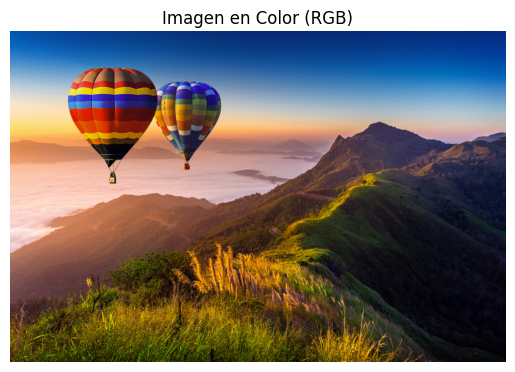

In [12]:
# 1. Descargar la imagen desde GitHub usando wget
!wget 'https://raw.githubusercontent.com/aoleonela-repositorio/Procesamiento_Img_Dig_TP2/main/data/landscape-morning-fog-mountains-with-hot-air-balloons-sunrise%20(1).jpg' -O imagen.jpg

# 2. Leer la imagen con OpenCV
img = cv2.imread('imagen.jpg')

# OpenCV carga las imágenes en formato BGR, así que convertimos a RGB para mostrar correctamente
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar la imagen en color
plt.imshow(img_rgb)
plt.title("Imagen en Color (RGB)")
plt.axis("off")
plt.show()

#**Paso 3: Mostrar las propiedades de la imágen**

In [13]:
print("Dimensiones (alto, ancho, canales):", img_rgb.shape)

Dimensiones (alto, ancho, canales): (4000, 6000, 3)


#**Paso 4: Convertir a escala de grises**

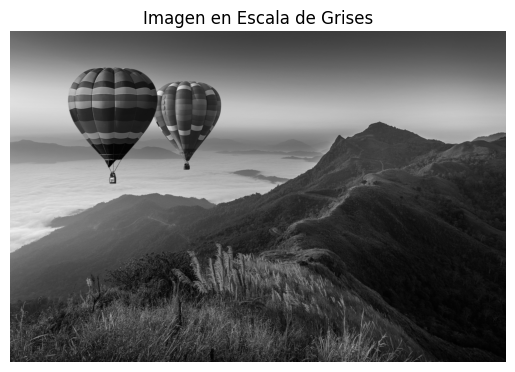

In [14]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title("Imagen en Escala de Grises")
plt.axis("off")
plt.show()

#**Paso 5: Mostrar una muestra de la matriz de píxeles**

In [15]:
print("Matriz de intensidades (ejemplo 10x10):")

# Primeros 10x10 píxeles

print(img_gray[0:10, 0:10])

Matriz de intensidades (ejemplo 10x10):
[[105 108 105  97 102 108 101 106 102  93]
 [ 97  96 107 106  97  99 107 110 109 106]
 [100 103 106 104  97  91  96 107 102 100]
 [104 113 105 100 102  96  91 102  93  98]
 [100 103 105 105 103 105 108 104  99 107]
 [ 99 100 105 105 102 109 113 106  98  99]
 [104 104 103 101 101 102 101 107  94  90]
 [101  99 103 102 100  95  96 111 102 101]
 [ 98  97  97 100  98 102 113 108 102 110]
 [100 105 102 100 105 109 107  95 100 108]]


#**Paso 6: Ajuste de contraste y brillo**

La imagen resultante se verá más clara y con mayor contraste que la original. Esto es útil cuando una imagen está demasiado oscura o plana, ya que mejora la visibilidad de detalles. Sin embargo, un exceso de contraste o brillo puede distorsionar la información (por ejemplo, perder detalles en zonas muy claras u oscuras).

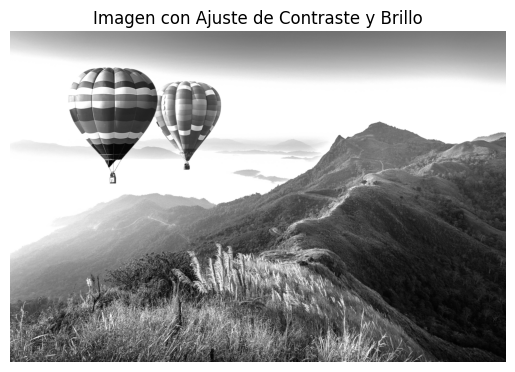

In [16]:
# alpha = contraste (1.0 = igual, >1 aumenta contraste)
# beta = brillo (0 = igual, valores positivos aumentan brillo)

img_contrast = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=50)

plt.imshow(img_contrast, cmap='gray')
plt.title("Imagen con Ajuste de Contraste y Brillo")
plt.axis("off")
plt.show()

#**Paso 7: Reducción de ruido con filtro espacial (Gaussiano)**

Las imágenes digitales suelen contener ruido: variaciones aleatorias de intensidad que no forman parte de la información real (por ejemplo, granulado en fotos con poca luz).
Para mejorar la calidad visual y facilitar el análisis, se aplican filtros de suavizado que reducen estas variaciones, como el filtro Gaussiano. Éste es uno de los más usados porque suaviza la imagen respetando mejor las transiciones entre zonas claras y oscuras que un filtro promedio simple.
Como resultado, la imagen se verá más limpia y homogénea, con menos puntos aleatorios o variaciones bruscas. Este proceso es útil como preprocesamiento antes de aplicar técnicas más avanzadas como detección de bordes o segmentación, ya que reduce falsos positivos causados por el ruido.
Sin embargo, un exceso de suavizado puede hacer que se pierdan detalles importantes (bordes finos o texturas).


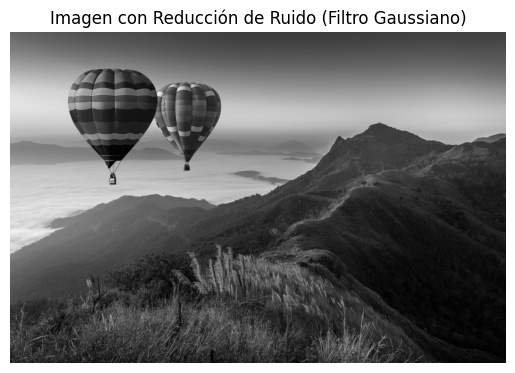

In [17]:
img_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
# (5,5) es el tamaño del kernel (matriz que se aplica sobre cada píxel). Cuanto más grande, más fuerte es el suavizado.
# 0 desviación estándar de la distribución Gaussiana. Si se deja en 0, OpenCV la calcula automáticamente en función del tamaño del kernel.

plt.imshow(img_blur, cmap='gray')
plt.title("Imagen con Reducción de Ruido (Filtro Gaussiano)")
plt.axis("off")
plt.show()

#**Paso 8: Histograma de intensidades**

Un *histograma* es una representación gráfica que muestra la frecuencia de aparición de cada nivel de intensidad en la imagen, e indica cuántos píxeles tienen cada valor de intensidad. En una imagen en escala de grises, los valores van de 0 (negro) a 255 (blanco).


*Interpretación del resultado:*

Si el histograma está concentrado en valores bajos (cerca de 0), la imagen es oscura, si está concentrado en valores altos (cerca de 255), la imagen es clara.
Si está distribuido de manera uniforme, la imagen tiene un buen contraste.
Si está muy concentrado en un rango estrecho, la imagen puede verse “lavada” o con poco contraste.


*Características visuales de la imágen:*

Concentración en valores bajos (40–60):
Hay un pico importante en intensidades oscuras. Esto indica que gran parte de la imagen contiene zonas con tonos oscuros o medios bajos, lo que sugiere que la imagen es predominantemente oscura.

Pequeños picos en valores altos (~200):
También aparecen algunas frecuencias en intensidades claras, aunque en menor cantidad. Esto significa que existen regiones brillantes o detalles luminosos, pero no son predominantes.

Distribución no uniforme:
El histograma no está extendido de manera pareja a lo largo de todo el rango (0–255). Esto implica que la imagen tiene un contraste limitado, ya que no se aprovechan todos los niveles de intensidad disponibles.

*Interpretación visual:*
La imagen probablemente se perciba con zonas oscuras dominantes y algunos puntos claros que resaltan. Puede dar la sensación de bajo contraste, donde los detalles en las sombras son más abundantes que los detalles en las luces.


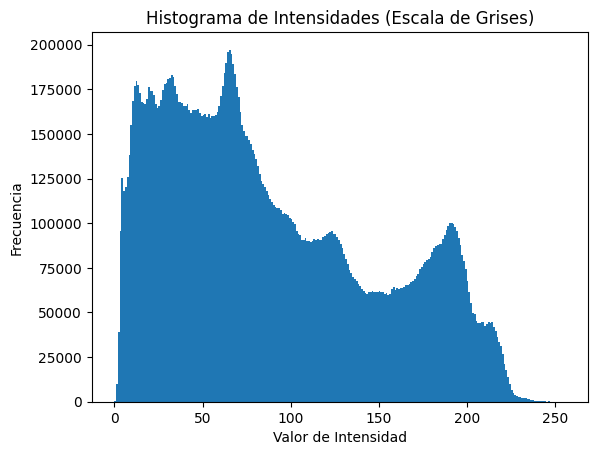

In [18]:
plt.hist(img_gray.ravel(), bins=256, range=[0,256])
plt.title("Histograma de Intensidades (Escala de Grises)")
plt.xlabel("Valor de Intensidad")
plt.ylabel("Frecuencia")
plt.show()

#**Conclusión**

La imagen en color muestra un paisaje con una amplia gama de tonalidades: desde los azules profundos del cielo hasta los naranjas cálidos del amanecer y los verdes intensos de las montañas. Al convertirla a escala de grises, se pierde la información cromática pero se conserva la estructura de intensidades, lo que permite analizar la composición visual en términos de luz y sombra.
El histograma obtenido refleja que la imagen tiene una predominancia de valores oscuros (zonas de montañas y sombras) y algunos picos en intensidades altas (zonas iluminadas por el sol y los globos). Esto confirma que la imagen posee un contraste natural, aunque no se aprovecha todo el rango dinámico de intensidades.
Los procesos aplicados —ajuste de contraste y brillo, reducción de ruido con filtro Gaussiano y análisis del histograma— muestran cómo se puede mejorar la visibilidad de detalles y preparar la imagen para tareas posteriores como segmentación o detección de bordes.
